# Análisis No Supervisado de Vinos: Clustering y Reducción de Dimensionalidad
_________________________
Autor: Joaquín Bocco

Proyecto personal de análisis no supervisado aplicado al dataset "Wine Quality".
_________________________________


## Objetivo
- Aplicar algoritmos de Clustering (KMeans, DBSCAN) para descubrir agrupaciones naturales en el dataset "Wine Quality".
- Utilizar técnicas de Reducción de Dimensionalidad (PCA, t-SNE, UMAP) para visualizar la estructura de los datos y los clusters.
- Interpretar los resultados de los métodos no supervisados y las visualizaciones, extrayendo conclusiones sobre la organización intrínseca de los datos de vino.

---

## Índice

1. [Imports y Configuración Inicial](#imports)
2. [Carga y Preparación de Datos](#carga)
3. [Análisis Exploratorio de Datos (EDA)](#eda)
4. [Clustering (Descubrir Grupos de Vino)](#clustering)
    - 4.1. [Preparación de Datos para Clustering](#prep_clustering)
    - 4.2. [Modelo de Clustering 1: KMeans](#kmeans)
    - 4.3. [Modelo de Clustering 2: DBSCAN](#dbscan)
    - 4.4. [Conclusión de Clustering](#conclusion_clustering)
5. [Reducción de Dimensionalidad y Visualización](#reduccion_dim)
    - 5.1. [Preparación de Datos para Reducción de Dimensionalidad](#prep_reduccion)
    - 5.2. [Técnica de Reducción 1: PCA para Visualización](#pca)
    - 5.3. [Técnica de Reducción 2: t-SNE para Visualización](#tsne)
    - 5.4. [Técnica de Reducción 3: UMAP para Visualización](#umap)
    - 5.5. [Conclusión de Reducción de Dimensionalidad](#conclusion_reduccion)
6. [Conclusiones Finales](#final)

---


<a name="imports"></a>
## 1. Imports y Configuración Inicial
En esta primera celda importo todas las librerías que voy a necesitar para el análisis de modelos no supervisados.

In [1]:
!pip install -q umap-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap # Asegúrate de tener instalado 'umap-learn': pip install umap-learn

# Métricas de evaluación para clustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a name="carga"></a>
## 2. Carga y Preparación de Datos
Cargo los dos datasets (vino tinto y vino blanco), agrego una columna para identificar el tipo de vino y los uno en un único DataFrame.

In [3]:
# URLs de los datasets
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

# Carga de los dataframes
df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# Creación de la columna 'wine_type' (0 para tinto, 1 para blanco)
df_red['wine_type'] = 0
df_white['wine_type'] = 1

# Unión de los dataframes
df = pd.concat([df_red, df_white], axis=0)

# Reseteamos el índice
df.reset_index(drop=True, inplace=True)

print("Forma del dataset combinado:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

Forma del dataset combinado: (6497, 13)

Primeras 5 filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


<a name="eda"></a>
## 3. Análisis Exploratorio de Datos (EDA)
Antes de modelar, es clave entender y preparar los datos.

Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

Estadísticas descriptivas de las variables numéric

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000



Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


/tmp/ipykernel_157/3525809640.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


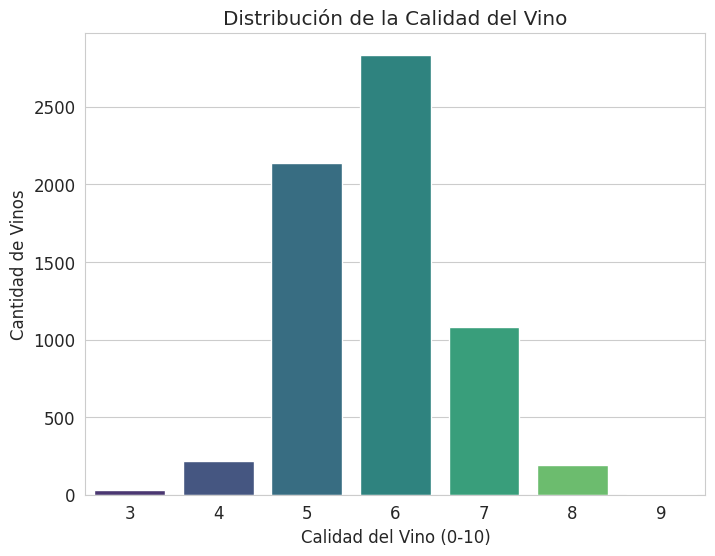

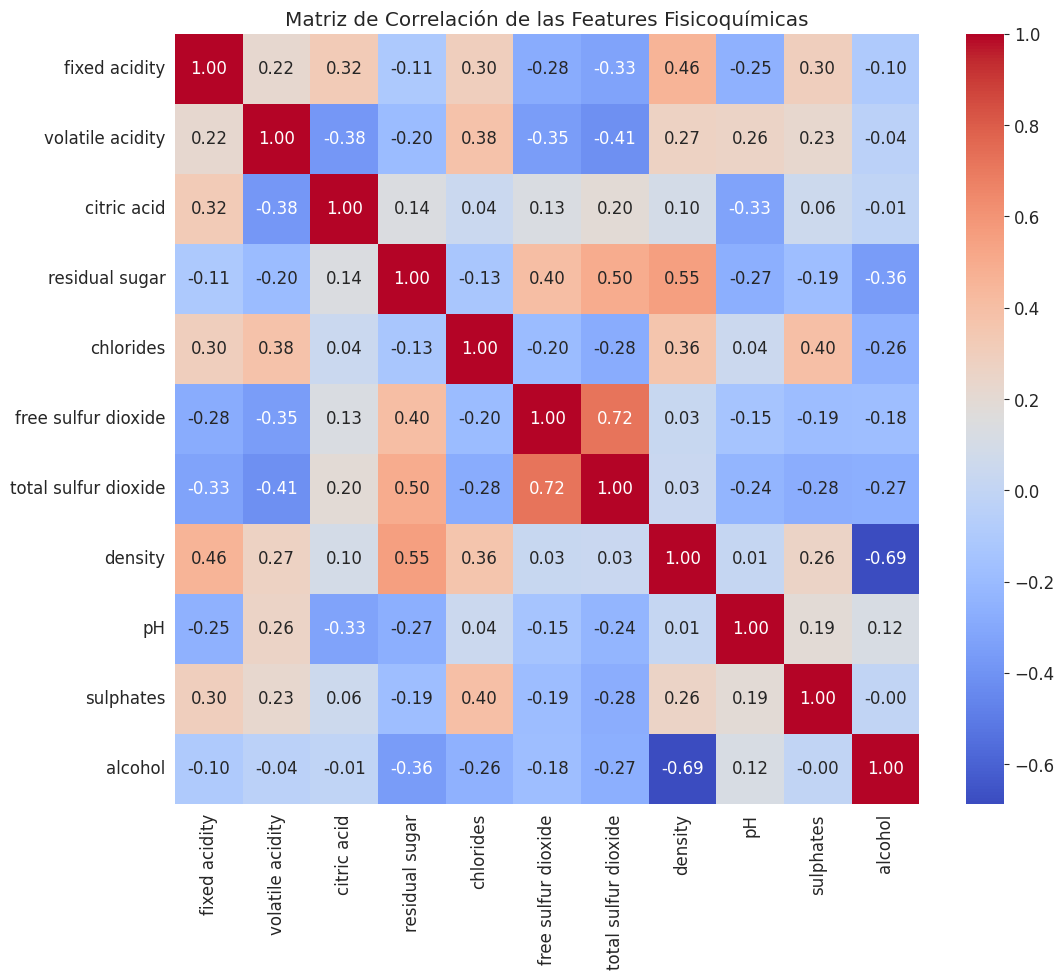

In [4]:
print("Información general del DataFrame:")
df.info()

print("\nEstadísticas descriptivas de las variables numéricas:")
display(df.describe())

print("\nValores nulos por columna:")
print(df.isnull().sum())

plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad del Vino (0-10)')
plt.ylabel('Cantidad de Vinos')
plt.show()

# Matriz de correlación de las variables fisicoquímicas
plt.figure(figsize=(12, 10))
# Excluimos las columnas 'wine_type' y 'quality' para la matriz de correlación de features
correlation_matrix = df.drop(['wine_type', 'quality'], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de las Features Fisicoquímicas')
plt.show()


### Análisis del EDA

De acuerdo al EDA, puedo observar:

La variable quality no está distribuida de manera uniforme: la mayoría de los registros se agrupan en valores intermedios (principalmente entre 5 y 6), mientras que los extremos aparecen con menor frecuencia. Este patrón es habitual en evaluaciones sensoriales.

Varias variables fisicoquímicas muestran distribuciones sesgadas, con colas hacia valores altos. Por ejemplo, residual sugar, chlorides y sulphates presentan observaciones poco frecuentes de gran magnitud (posibles outliers).
Esto es relevante porque los algoritmos basados en distancias son sensibles tanto a la escala como a valores extremos, por lo que la estandarización de las variables resulta necesaria.

⸻

Valores faltantes

En este conjunto de datos no suelen aparecer valores nulos; al aplicar isnull() debería obtenerse cero en todas las columnas.
Por lo tanto, no se requiere imputación, aunque sí es prudente examinar la presencia de outliers.

⸻

Relaciones entre variables

Se observa una correlación positiva entre density y residual sugar, y una correlación negativa entre density y alcohol. Esto es coherente desde el punto de vista físico: mayor contenido de azúcar incrementa la densidad, mientras que mayor graduación alcohólica tiende a reducirla.

Las variables free sulfur dioxide y total sulfur dioxide presentan correlación positiva, lo cual es esperable dado que están conceptualmente relacionadas.

También se detectan correlaciones moderadas entre ciertas variables, como fixed acidity y citric acid, lo que podría introducir redundancia en el modelo.


<a name="clustering"></a>
## 4. Clustering (Descubrir Grupos de Vino)
En esta sección aplico algoritmos de clustering para identificar agrupaciones naturales dentro del dataset de vinos, sin utilizar las etiquetas de `wine_type` o `quality`.

<a name="prep_clustering"></a>
### 4.1. Preparación de Datos para Clustering
Para el clustering, solo uso las características fisicoquímicas de los vinos, y es **crucial** que estén escaladas. Las etiquetas originales (`wine_type`, `quality`) las guardo para una posterior comparación y análisis.

In [5]:
# Definir X (features) y las etiquetas originales (y_type, y_quality) para comparación
X = df.drop(['wine_type', 'quality'], axis=1)
y_type = df['wine_type']
y_quality = df['quality']

print(f"Dimensiones de X para clustering: {X.shape}")

# Escalar las características (fundamental para algoritmos basados en distancia)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nPrimeras 5 filas de X escalado:")
print(pd.DataFrame(X_scaled, columns=X.columns).head())

Dimensiones de X para clustering: (6497, 11)

Primeras 5 filas de X escalado:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.142473          2.188833    -2.192833       -0.744778   0.569958   
1       0.451036          3.282235    -2.192833       -0.597640   1.197975   
2       0.451036          2.553300    -1.917553       -0.660699   1.026697   
3       3.073817         -0.362438     1.661085       -0.744778   0.541412   
4       0.142473          2.188833    -2.192833       -0.744778   0.569958   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -1.100140             -1.446359  1.034993  1.813090   0.193097   
1            -0.311320             -0.862469  0.701486 -0.115073   0.999579   
2            -0.874763             -1.092486  0.768188  0.258120   0.797958   
3            -0.762074             -0.986324  1.101694 -0.363868   0.327510   
4            -1.100140             -1.446359  1.034993  1.

<a name="kmeans"></a>
### 4.2. Modelo de Clustering 1: KMeans
KMeans es un algoritmo de clustering que busca dividir $N$ observaciones en $K$ clusters, donde cada observación pertenece al cluster con la media (centroide) más cercana. Es nuestro punto de partida para identificar grupos.

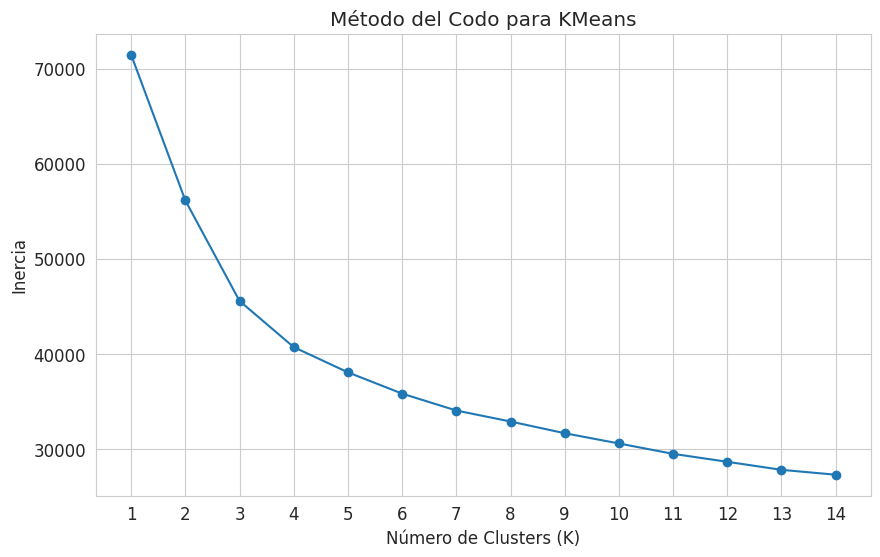

In [6]:
inertia = []
k_range_inertia = range(1, 15) # Probamos K desde 1 hasta 14

for k in k_range_inertia:
    # n_init='auto' es el valor por defecto para versiones recientes, o 10 para compatibilidad.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range_inertia, inertia, marker='o')
plt.title('Método del Codo para KMeans')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(k_range_inertia)
plt.grid(True)
plt.show()

# K=3: primer punto donde la curva de inercia se aplana claramente. Se confirma
# más abajo con Silhouette / Calinski-Harabasz / Davies-Bouldin.
k_elegido = 3


#### Elegí k=3 porque es el primer punto donde, según mi lectura del gráfico, la curva se aplana.

In [7]:
if k_elegido is not None:
    kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
    clusters_kmeans = kmeans_final.fit_predict(X_scaled)

    print(f"Número de puntos por cluster (KMeans con K={k_elegido}):")
    print(pd.Series(clusters_kmeans).value_counts().sort_index())
else:
    print("Por favor, define 'k_elegido' en la celda anterior.")

Número de puntos por cluster (KMeans con K=3):
0    1896
1    1592
2    3009
Name: count, dtype: int64


In [8]:
if 'clusters_kmeans' in locals():
    silhouette_avg_kmeans = silhouette_score(X_scaled, clusters_kmeans)
    print(f"Silhouette Score para KMeans (K={k_elegido}): {silhouette_avg_kmeans:.3f}")

    calinski_kmeans = calinski_harabasz_score(X_scaled, clusters_kmeans)
    davies_kmeans = davies_bouldin_score(X_scaled, clusters_kmeans)
    print(f"Calinski-Harabasz Score para KMeans: {calinski_kmeans:.3f}")
    print(f"Davies-Bouldin Score para KMeans: {davies_kmeans:.3f}")
else:
    print("Por favor, ejecuta las celdas anteriores para generar los clusters de KMeans.")

Silhouette Score para KMeans (K=3): 0.235
Calinski-Harabasz Score para KMeans: 1844.457
Davies-Bouldin Score para KMeans: 1.484


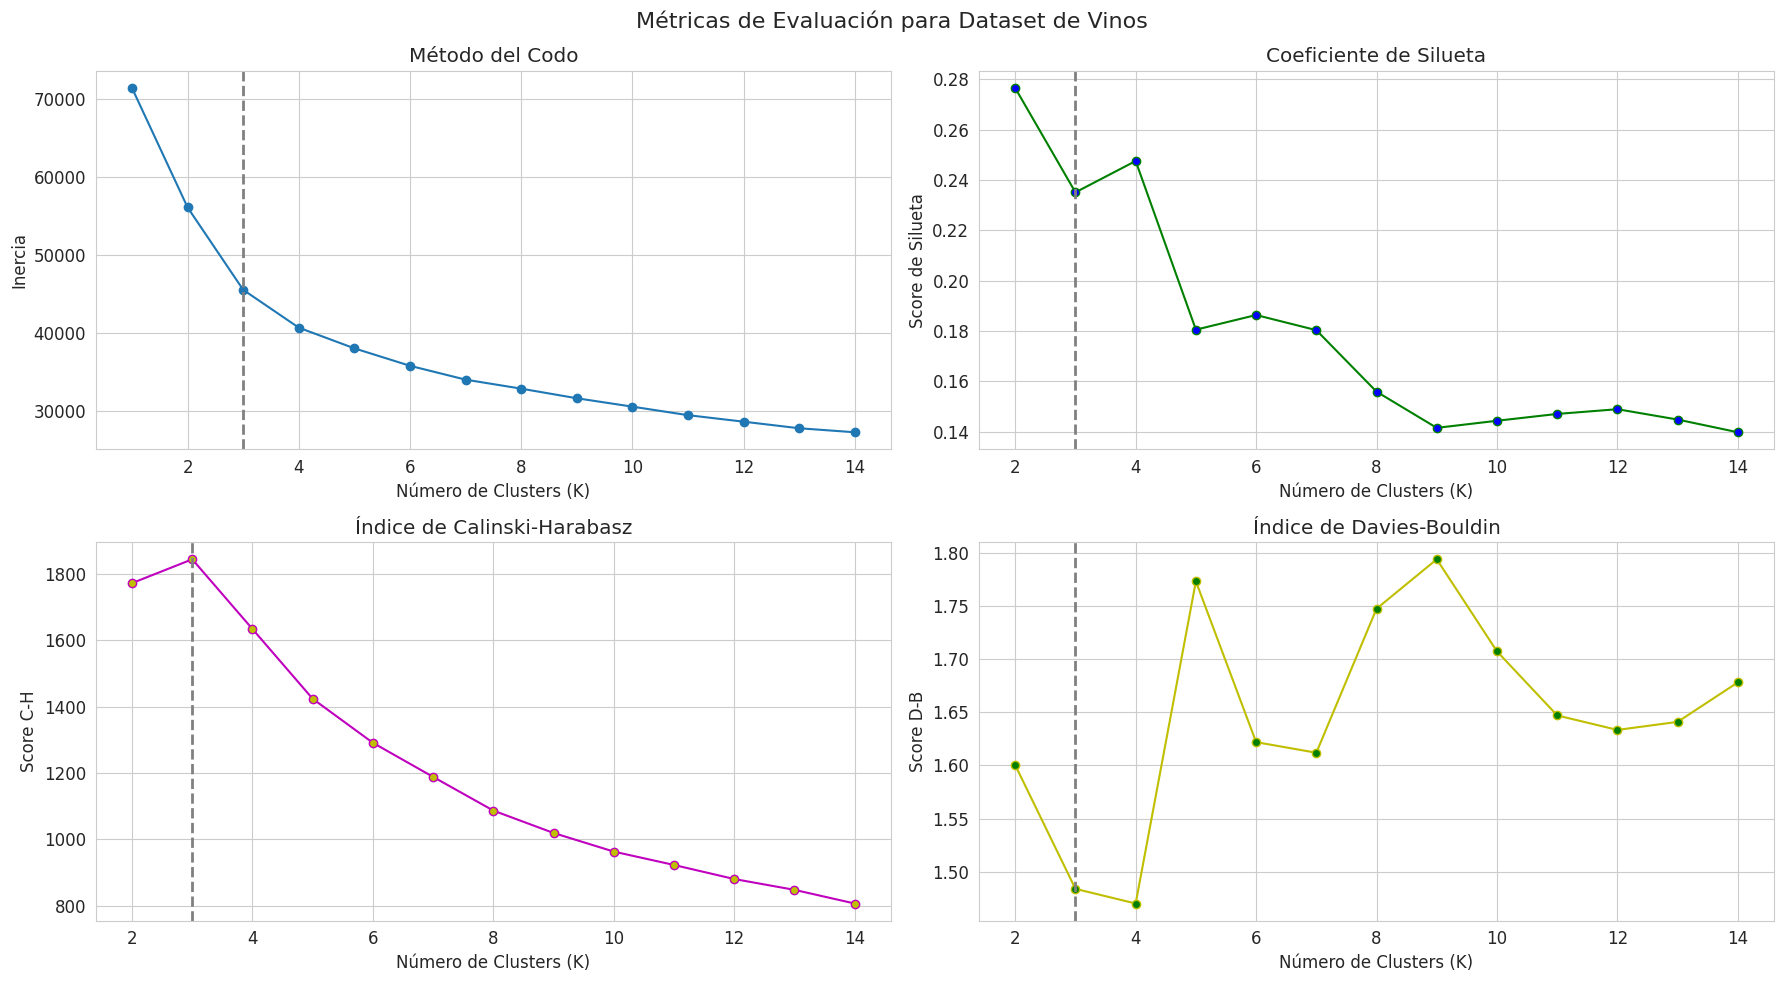

In [9]:
silhouette_scores = []
calinski_scores = []
davies_scores = []

k_range_metrics = range(2, 15) #Utilizo otro rango ya que silueta puede hacerse desde k=2

for k in k_range_metrics:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))


resultados_vinos = pd.DataFrame({
    'Silueta': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_scores
}, index=k_range_metrics)


fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Métricas de Evaluación para Dataset de Vinos', fontsize=16)

#  Método del Codo
axes[0, 0].plot(k_range_inertia, inertia, marker='o')
axes[0, 0].set_title('Método del Codo')
axes[0, 0].set_xlabel('Número de Clusters (K)')
axes[0, 0].set_ylabel('Inercia')
axes[0, 0].axvline(x=k_elegido, color='grey', linestyle='--', linewidth=2)

#  Silhouette
axes[0, 1].plot(resultados_vinos.index, resultados_vinos['Silueta'], 'go-', markerfacecolor='b')
axes[0, 1].set_title('Coeficiente de Silueta')
axes[0, 1].set_xlabel('Número de Clusters (K)')
axes[0, 1].set_ylabel('Score de Silueta')
axes[0, 1].axvline(x=k_elegido, color='grey', linestyle='--', linewidth=2)

#  Calinski-Harabasz
axes[1, 0].plot(resultados_vinos.index, resultados_vinos['Calinski-Harabasz'], 'mo-', markerfacecolor='y')
axes[1, 0].set_title('Índice de Calinski-Harabasz')
axes[1, 0].set_xlabel('Número de Clusters (K)')
axes[1, 0].set_ylabel('Score C-H')
axes[1, 0].axvline(x=k_elegido, color='grey', linestyle='--', linewidth=2)

#  Davies-Bouldin
axes[1, 1].plot(resultados_vinos.index, resultados_vinos['Davies-Bouldin'], 'yo-', markerfacecolor='g')
axes[1, 1].set_title('Índice de Davies-Bouldin')
axes[1, 1].set_xlabel('Número de Clusters (K)')
axes[1, 1].set_ylabel('Score D-B')
axes[1, 1].axvline(x=k_elegido, color='grey', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

De acuerdo a lo observado el coeficiente de Silueta alcanza su valor máximo en K=2, tanto el Método del Codo como los índices de Calinski-Harabasz y Davies-Bouldin coinciden con K = 3 que representa el mejor equilibrio entre cohesión interna y separación entre grupos.

Por lo tanto, se selecciona K = 3 como número óptimo de clusters, ya que ofrece una segmentación interpretable y estructuralmente sólida.

<a name="dbscan"></a>
### 4.3. Modelo de Clustering 2: DBSCAN
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo basado en densidad que agrupa puntos que están densamente conectados, marcando como ruido los puntos que se encuentran en regiones de baja densidad.

In [10]:
!pip install kneed
from kneed import KneeLocator

def detectar_eps_robusto(X, min_samples=2*11, suavizado=5, recorte_ratio=0.95, show_plot=True):
    """
    Detección robusta de eps para DBSCAN usando recorte, suavizado y Kneedle.

    Parámetros:
    - X: array-like, datos de entrada
    - min_samples: int, número de vecinos para DBSCAN y K-Distance, USAMOS LA REGLA 2*N_FEATURES
    - suavizado: int, tamaño de ventana para suavizar la curva
    - recorte_ratio: float, porcentaje de puntos a conservar (por ej. 0.95 = 95%)
    - show_plot: bool, si se desea mostrar el gráfico

    Retorna:
    - eps_sugerido: float
    """

    # Paso 1: Vecinos más cercanos
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    k_distances = np.sort(distances[:, min_samples - 1])

    # Paso 2: Recorte de la cola (para evitar extremos)
    n_puntos = int(len(k_distances) * recorte_ratio)
    k_distances = k_distances[:n_puntos]

    # Paso 3: Suavizado con media móvil
    if suavizado > 1:
        k_distances_suavizado = np.convolve(k_distances, np.ones(suavizado)/suavizado, mode='valid')
    else:
        k_distances_suavizado = k_distances

    # Paso 4: Aplicación de Kneedle
    kneedle = KneeLocator(
        range(len(k_distances_suavizado)),
        k_distances_suavizado,
        curve='convex',
        direction='increasing'
    )

    knee_idx = kneedle.knee
    eps_sugerido = k_distances_suavizado[knee_idx] if knee_idx is not None else None

    # Paso 5: Gráfico (opcional)
    if show_plot:
        plt.figure(figsize=(12, 6))
        plt.plot(k_distances, label='Distancias (recortadas)')
        plt.plot(k_distances_suavizado, label='Suavizado', linestyle='--')
        if knee_idx is not None:
            plt.axvline(knee_idx, color='gray', linestyle='--', label=f'Índice del codo')
            plt.axhline(eps_sugerido, color='red', linestyle='--', label=f'Eps sugerido ≈ {eps_sugerido:.3f}')
        else:
            plt.title("No se detectó codo automáticamente.")
        plt.xlabel("Puntos ordenados")
        plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
        plt.title("K-Distance Plot con detección robusta del codo")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    return eps_sugerido


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

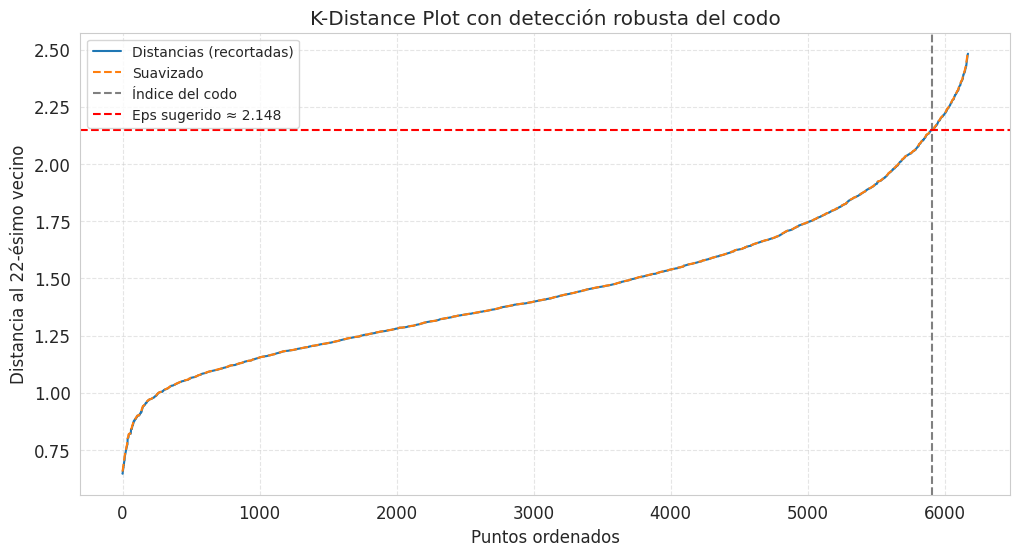

eps sugerido automáticamente: 2.148


In [11]:
# min_samples: regla práctica 2 * n_features (11 variables fisicoquímicas -> 22)
min_samples_dbscan = 2 * X_scaled.shape[1]

# Detección automática y reproducible de eps a partir del K-distance plot (Kneedle).
# Antes esto se leía a ojo del gráfico y se hardcodeaba un número aparte; ahora
# eps_elegido queda atado al resultado real de la función.
eps_elegido = detectar_eps_robusto(X_scaled, min_samples=min_samples_dbscan)
print(f"eps sugerido automáticamente: {eps_elegido:.3f}")


A partir del análisis del gráfico K-Distance, se identifica un punto de inflexión marcado en torno a ε ≈ 2.1–2.2. Este “codo” representa el umbral a partir del cual las distancias comienzan a incrementarse de forma abrupta, indicando la transición entre regiones densas del espacio de datos y puntos aislados.

Este valor de ε permite diferenciar adecuadamente entre observaciones pertenecientes a clusters y aquellas consideradas ruido (outliers), estableciendo un radio de vecindad coherente con la estructura interna del dataset. La porción inicial suave de la curva corresponde a áreas de alta densidad, mientras que el crecimiento pronunciado al final refleja puntos dispersos.

Por lo tanto, se adopta como parámetro óptimo para DBSCAN el valor de `eps_elegido` calculado automáticamente arriba (≈2.148 al ejecutar este análisis por primera vez), ya que equilibra la identificación de agrupamientos significativos con la detección de anomalías, evitando tanto la sobre–segmentación como la pérdida de estructura.


In [12]:
if eps_elegido is not None:
    dbscan_final = DBSCAN(eps=eps_elegido, min_samples=min_samples_dbscan)
    clusters_dbscan = dbscan_final.fit_predict(X_scaled)

    print(f"Número de puntos por cluster (DBSCAN con eps={eps_elegido}, min_samples={min_samples_dbscan}):")
    print(pd.Series(clusters_dbscan).value_counts().sort_index())
else:
    print("Por favor, define 'eps_elegido' en la celda anterior.")

Número de puntos por cluster (DBSCAN con eps=2.1480147510466274, min_samples=22):
-1     206
 0    6291
Name: count, dtype: int64


In [13]:
if 'clusters_dbscan' in locals():
    valid_indices = clusters_dbscan != -1
    if np.unique(clusters_dbscan[valid_indices]).size > 1: # Asegurarse de que haya al menos 2 clusters válidos
        silhouette_avg_dbscan = silhouette_score(X_scaled[valid_indices], clusters_dbscan[valid_indices])
        print(f"Silhouette Score para DBSCAN (excluyendo ruido): {silhouette_avg_dbscan:.3f}")

        calinski_dbscan = calinski_harabasz_score(X_scaled[valid_indices], clusters_dbscan[valid_indices])
        davies_dbscan = davies_bouldin_score(X_scaled[valid_indices], clusters_dbscan[valid_indices])
        print(f"Calinski-Harabasz Score para DBSCAN: {calinski_dbscan:.3f}")
        print(f"Davies-Bouldin Score para DBSCAN: {davies_dbscan:.3f}")
    else:
        print("No hay suficientes clusters válidos (más de 1) en DBSCAN para calcular Silhouette Score.")
else:
    print("Por favor, ejecuta las celdas anteriores para generar los clusters de DBSCAN.")

No hay suficientes clusters válidos (más de 1) en DBSCAN para calcular Silhouette Score.


<a name="conclusion_clustering"></a>
### 4.4. Conclusión de Clustering
No basta con aplicar los algoritmos; es clave entender qué me dicen los clusters y cuál enfoque es más adecuado para este dataset de vinos.

In [14]:
print("\n--- Comparación de Métricas de Clustering ---")

sil_k, sil_d = None, None

if 'silhouette_avg_kmeans' in locals():
    sil_k = float(silhouette_avg_kmeans)
    print(f"KMeans (k={k_elegido}): Silhouette Score = {sil_k:.3f}")
if 'silhouette_avg_dbscan' in locals():
    sil_d = float(silhouette_avg_dbscan)
    print(f"DBSCAN (eps={eps_elegido:.3f}, min_samples={min_samples_dbscan}): Silhouette Score = {sil_d:.3f}")

print("\n--- Comentario guiado ---")
if sil_k is not None and sil_d is not None:
    if sil_k > sil_d:
        print("✅ Por Silhouette, KMeans separa mejor (clusters más compactos y más separados).")
        print("   Igual, DBSCAN puede ser útil si queremos detectar ruido/outliers o clusters no esféricos.")
    elif sil_d > sil_k:
        print("✅ Por Silhouette, DBSCAN separa mejor con estos parámetros.")
        print("   Además, DBSCAN puede marcar ruido (-1), lo cual aporta interpretabilidad en presencia de outliers.")
    else:
        print("⚖️ Ambos métodos dan un Silhouette similar. Elegimos por interpretabilidad y estabilidad.")
elif sil_k is not None:
    print("✅ Tenemos Silhouette para KMeans. Si DBSCAN no dio métrica, suele ser por ruido excesivo o 1 solo cluster.")
elif sil_d is not None:
    print("✅ Tenemos Silhouette para DBSCAN. Si KMeans no dio métrica, revisamos si hubo algún error previo.")
else:
    print("No hay Silhouette disponible. Verificamos que ambos modelos hayan generado al menos 2 clusters.")



--- Comparación de Métricas de Clustering ---
KMeans (k=3): Silhouette Score = 0.235

--- Comentario guiado ---
✅ Tenemos Silhouette para KMeans. Si DBSCAN no dio métrica, suele ser por ruido excesivo o 1 solo cluster.


En esta etapa comparé KMeans y DBSCAN utilizando el Silhouette Score como métrica de evaluación. Sin embargo, DBSCAN no generó un Silhouette válido, lo que indica que con los parámetros actuales el algoritmo produjo un único cluster, lo que impide continuar el análisis.

Por este motivo, decidí avanzar con KMeans, que sí logró generar múltiples clusters y permitió calcular el Silhouette Score. Esto sugiere que KMeans se adapta mejor a la estructura, formando grupos más estables.

In [15]:
# Elegimos clusters_kmeans: como se concluyó en la sección anterior, DBSCAN no
# logró generar más de un cluster con estos datos y parámetros, así que no
# aporta información nueva para este cruce.
clusters_para_analisis = clusters_kmeans

if 'clusters_para_analisis' in locals():
    # Análisis de clusters vs. Tipo de Vino
    print("\n--- Análisis de Clusters vs. Tipo de Vino Original ---")
    crosstab_type = pd.crosstab(clusters_para_analisis, y_type)
    display(crosstab_type)

    # Análisis de clusters vs. Calidad del Vino
    print("\n--- Análisis de Clusters vs. Calidad del Vino Original ---")
    crosstab_quality = pd.crosstab(clusters_para_analisis, y_quality)
    display(crosstab_quality)
else:
    print("Por favor, asegúrate de que 'clusters_kmeans' o 'clusters_dbscan' estén definidos.")



--- Análisis de Clusters vs. Tipo de Vino Original ---


wine_type,0,1
row_0,,
0,4,1892
1,1538,54
2,57,2952



--- Análisis de Clusters vs. Calidad del Vino Original ---


quality,3,4,5,6,7,8,9
row_0,,,,,,,
0,12,48,804,844,157,30,1
1,10,68,696,621,182,15,0
2,8,100,638,1371,740,148,4


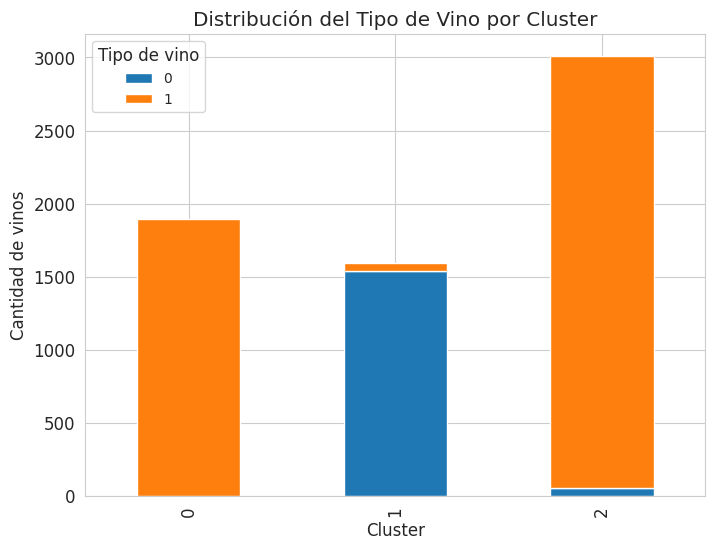

In [16]:
# Conteo absoluto
crosstab_type = pd.crosstab(clusters_para_analisis, y_type)

crosstab_type.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Distribución del Tipo de Vino por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de vinos")
plt.legend(title="Tipo de vino")
plt.show()


| Algoritmo | Parámetros Clave (K / eps, min_samples) | Nº Clusters Encontrados | Nº Outliers (DBSCAN) | Silhouette Score |
|-----------|-----------------------------------------|-------------------------|----------------------|------------------|
| KMeans    | K = 3                                    | 3                        | N/A                  | 0.235            |
| DBSCAN    | eps ≈ 2.148, min_samples = 22            | 1                        | 206                  | No disponible    |


Basado en las métricas, el análisis de clusters frente a las etiquetas originales y las observaciones, concluyo que KMeans es el algoritmo más adecuado.

Con K = 3, KMeans logró identificar tres clusters bien definidos, permitiendo calcular el Silhouette Score y evidenciando una separación por tipo de vino, con un cluster compuesto por vinos tintos y dos clusters mayormente formados por vinos blancos. Asimismo, los clusters presentaron diferencias en los niveles de calidad, destacándose un grupo con mayor concentración de vinos de calidad media-alta, lo que demuestra que el modelo capturó patrones relevantes presentes en los datos.

Por el contrario, DBSCAN, con eps = 2.148, generó un único cluster y clasificó 206 observaciones como outliers, lo que impidió calcular el Silhouette Score y avanzar con un análisis significativo. Si bien DBSCAN es útil para detectar formas no esféricas y ruido, en este caso no logró adaptarse a la estructura del dataset, perdiendo interpretabilidad y capacidad de segmentación.

En conclusión, KMeans ofrece mayor estabilidad, interpretabilidad y capacidad para encontrar patrones significativos en este conjunto de datos, por lo que lo adopto como el modelo principal de clustering para el análisis.

<a name="reduccion_dim"></a>
## 5. Reducción de Dimensionalidad y Visualización
Dado que los datos tienen 11 características, es difícil visualizarlos directamente. Aplico técnicas de reducción de dimensionalidad para proyectar los datos a 2 dimensiones y así poder ver la estructura de los clusters encontrados.

<a name="prep_reduccion"></a>
### 5.1. Preparación de Datos para Reducción de Dimensionalidad
La entrada para las técnicas de reducción de dimensionalidad serán los datos escalados (`X_scaled`) que preparamos previamente.

In [17]:
print(f"Los datos de entrada para la reducción de dimensionalidad son X_scaled con forma: {X_scaled.shape}")


Los datos de entrada para la reducción de dimensionalidad son X_scaled con forma: (6497, 11)


<a name="pca"></a>
### 5.2. Técnica de Reducción 1: PCA para Visualización
PCA (Principal Component Analysis) es una técnica de reducción de dimensionalidad lineal que busca las direcciones (componentes principales) en los datos que maximizan la varianza.

In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma de los datos después de PCA: {X_pca.shape}")

Forma de los datos después de PCA: (6497, 2)


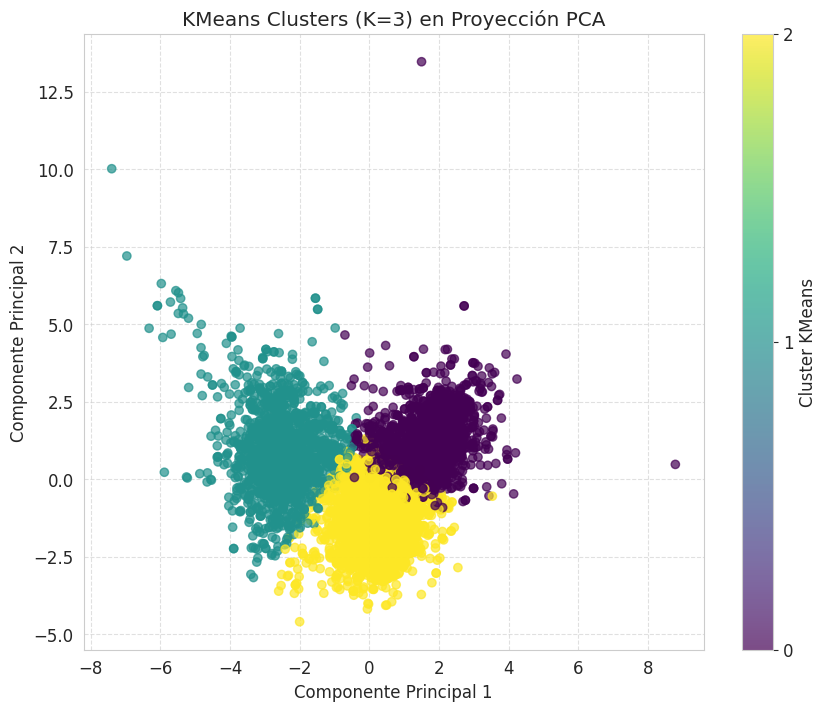

In [19]:
if 'clusters_kmeans' in locals():
    plt.figure(figsize=(10, 8))
    scatter_kmeans_pca = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.7)
    plt.title(f'KMeans Clusters (K={k_elegido}) en Proyección PCA')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.colorbar(scatter_kmeans_pca, label='Cluster KMeans', ticks=range(k_elegido))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de KMeans para obtener 'clusters_kmeans'.")

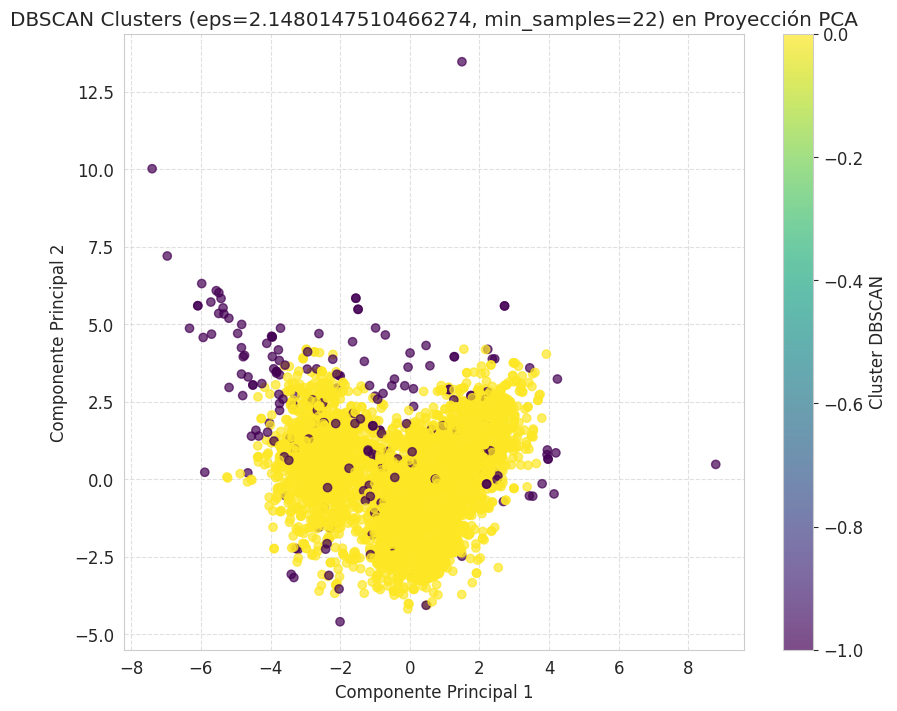

In [20]:
if 'clusters_dbscan' in locals():
    plt.figure(figsize=(10, 8))
    scatter_dbscan_pca = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='viridis', alpha=0.7)
    plt.title(f'DBSCAN Clusters (eps={eps_elegido}, min_samples={min_samples_dbscan}) en Proyección PCA')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.colorbar(scatter_dbscan_pca, label='Cluster DBSCAN')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de DBSCAN para obtener 'clusters_dbscan'.")

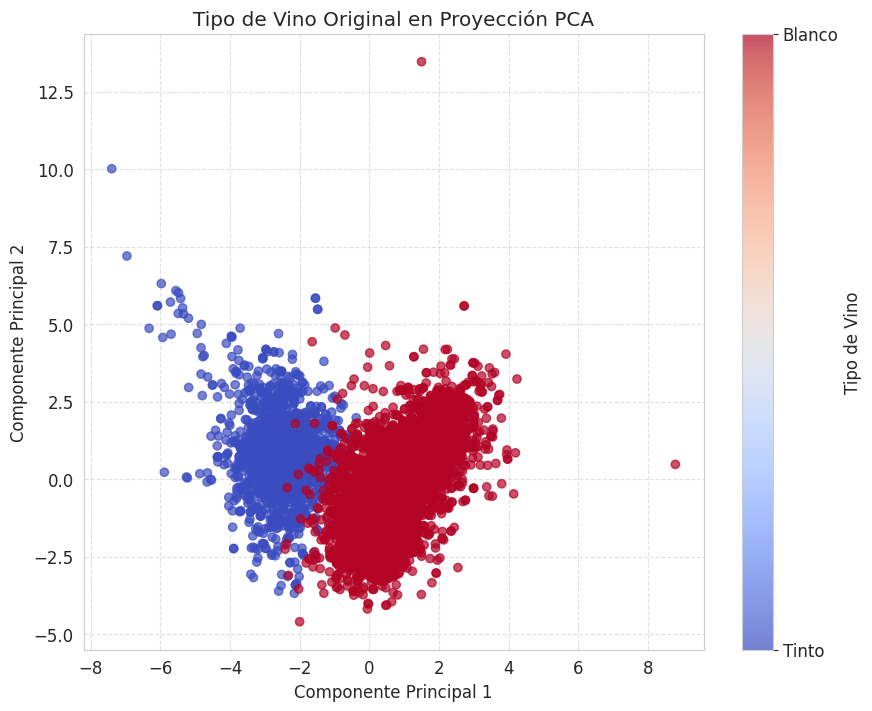

In [21]:
plt.figure(figsize=(10, 8))
scatter_original_pca = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_type, cmap='coolwarm', alpha=0.7)
plt.title('Tipo de Vino Original en Proyección PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter_original_pca, ticks=[0, 1], format=plt.FuncFormatter(lambda x, p: 'Tinto' if x==0 else 'Blanco'), label='Tipo de Vino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<a name="tsne"></a>
### 5.3. Técnica de Reducción 2: t-SNE para Visualización
t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica no lineal que se enfoca en preservar las relaciones de proximidad local, lo que la hace excelente para visualizar agrupamientos (clusters).

In [22]:
print("Ejecutando t-SNE... (esto puede tomar un tiempo considerable)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print(f"Forma de los datos después de t-SNE: {X_tsne.shape}")


Ejecutando t-SNE... (esto puede tomar un tiempo considerable)


Forma de los datos después de t-SNE: (6497, 2)


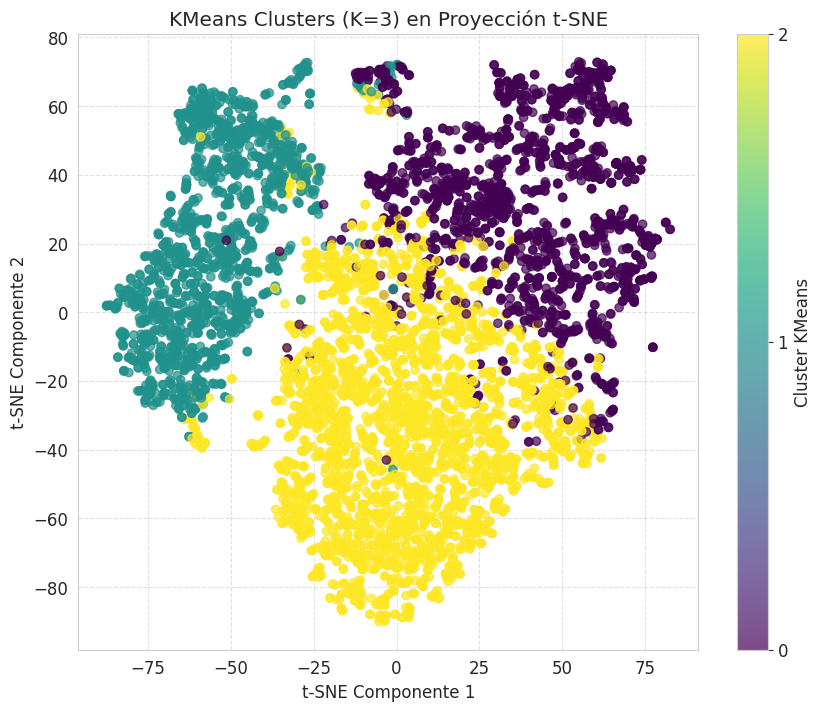

In [23]:
if 'clusters_kmeans' in locals():
    plt.figure(figsize=(10, 8))
    scatter_kmeans_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.7)
    plt.title(f'KMeans Clusters (K={k_elegido}) en Proyección t-SNE')
    plt.xlabel('t-SNE Componente 1')
    plt.ylabel('t-SNE Componente 2')
    plt.colorbar(scatter_kmeans_tsne, label='Cluster KMeans', ticks=range(k_elegido))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de KMeans para obtener 'clusters_kmeans'.")


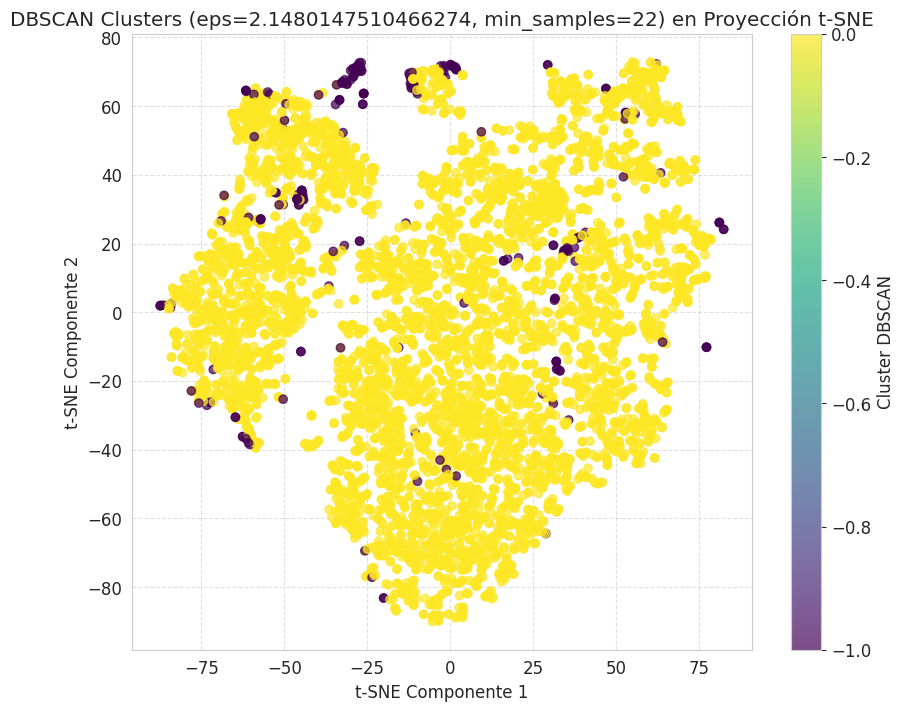

In [24]:
if 'clusters_dbscan' in locals():
    plt.figure(figsize=(10, 8))
    scatter_dbscan_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_dbscan, cmap='viridis', alpha=0.7)
    plt.title(f'DBSCAN Clusters (eps={eps_elegido}, min_samples={min_samples_dbscan}) en Proyección t-SNE')
    plt.xlabel('t-SNE Componente 1')
    plt.ylabel('t-SNE Componente 2')
    plt.colorbar(scatter_dbscan_tsne, label='Cluster DBSCAN')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de DBSCAN para obtener 'clusters_dbscan'.")

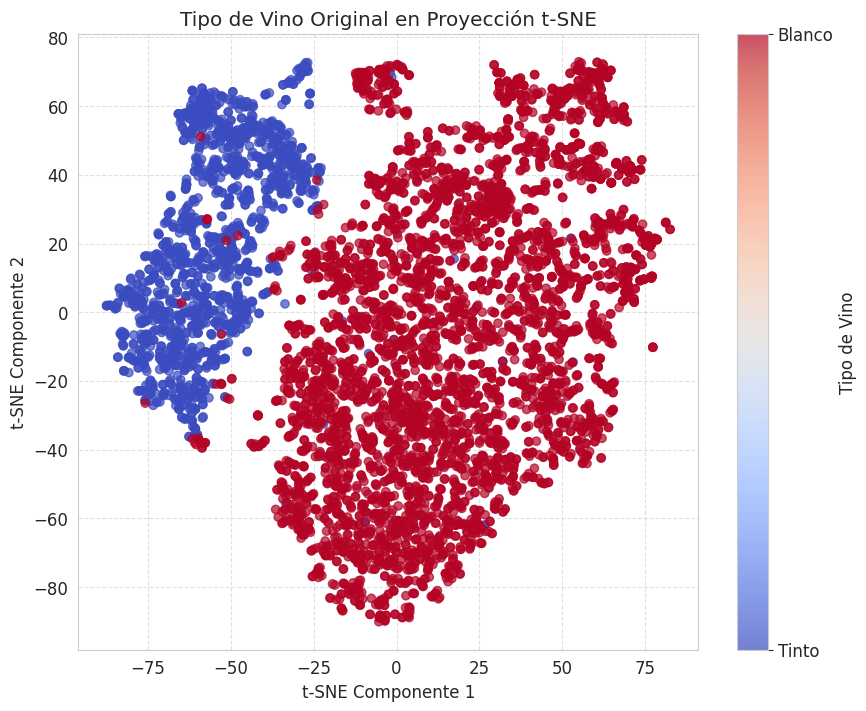

In [25]:
plt.figure(figsize=(10, 8))
scatter_original_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_type, cmap='coolwarm', alpha=0.7)
plt.title('Tipo de Vino Original en Proyección t-SNE')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.colorbar(scatter_original_tsne, ticks=[0, 1], format=plt.FuncFormatter(lambda x, p: 'Tinto' if x==0 else 'Blanco'), label='Tipo de Vino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<a name="umap"></a>
### 5.4. Técnica de Reducción 3: UMAP para Visualización
UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad no lineal más reciente y a menudo más rápida que t-SNE, que busca un balance entre la preservación de la estructura local y global.

In [26]:
print("Ejecutando UMAP... (generalmente más rápido que t-SNE)")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1) # Ajusta parámetros si es necesario
X_umap = reducer.fit_transform(X_scaled)

print(f"Forma de los datos después de UMAP: {X_umap.shape}")

Ejecutando UMAP... (generalmente más rápido que t-SNE)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Forma de los datos después de UMAP: (6497, 2)


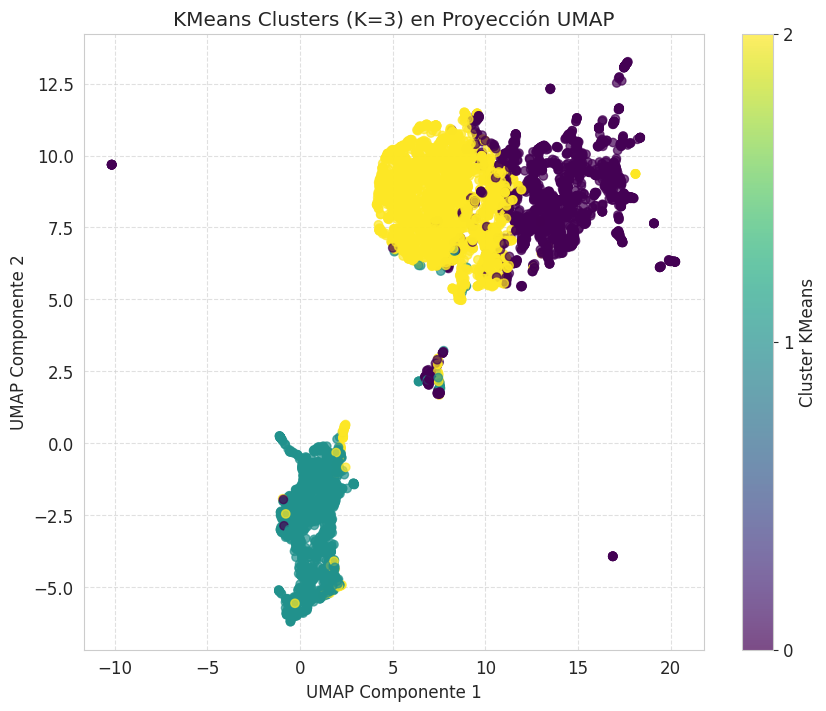

In [27]:
if 'clusters_kmeans' in locals():
    plt.figure(figsize=(10, 8))
    scatter_kmeans_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.7)
    plt.title(f'KMeans Clusters (K={k_elegido}) en Proyección UMAP')
    plt.xlabel('UMAP Componente 1')
    plt.ylabel('UMAP Componente 2')
    plt.colorbar(scatter_kmeans_umap, label='Cluster KMeans', ticks=range(k_elegido))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de KMeans para obtener 'clusters_kmeans'.")

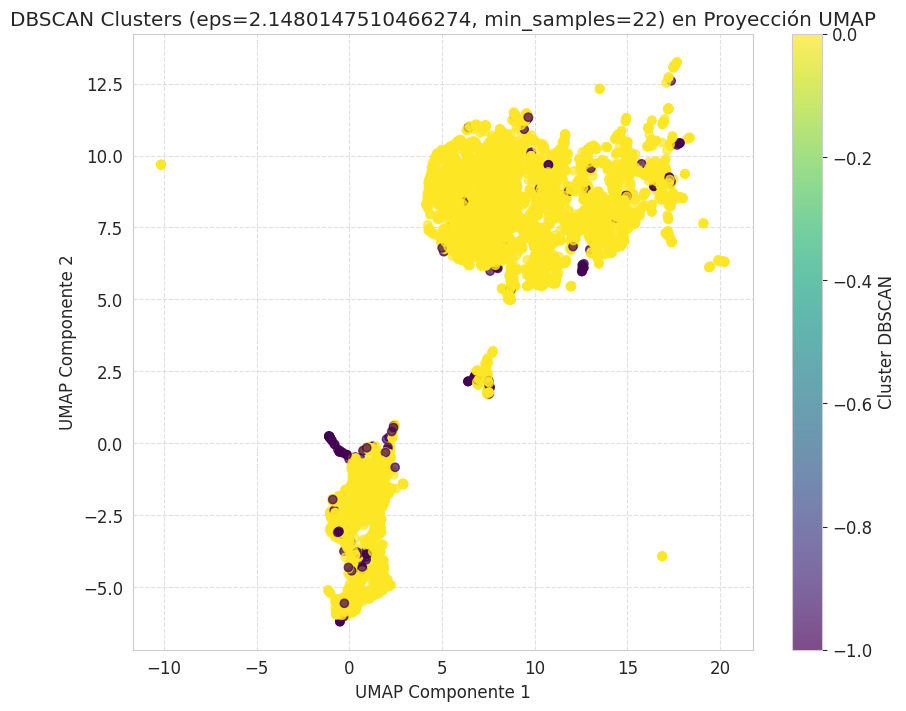

In [28]:
if 'clusters_dbscan' in locals():
    plt.figure(figsize=(10, 8))
    scatter_dbscan_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters_dbscan, cmap='viridis', alpha=0.7)
    plt.title(f'DBSCAN Clusters (eps={eps_elegido}, min_samples={min_samples_dbscan}) en Proyección UMAP')
    plt.xlabel('UMAP Componente 1')
    plt.ylabel('UMAP Componente 2')
    plt.colorbar(scatter_dbscan_umap, label='Cluster DBSCAN')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Por favor, ejecuta la sección de DBSCAN para obtener 'clusters_dbscan'.")

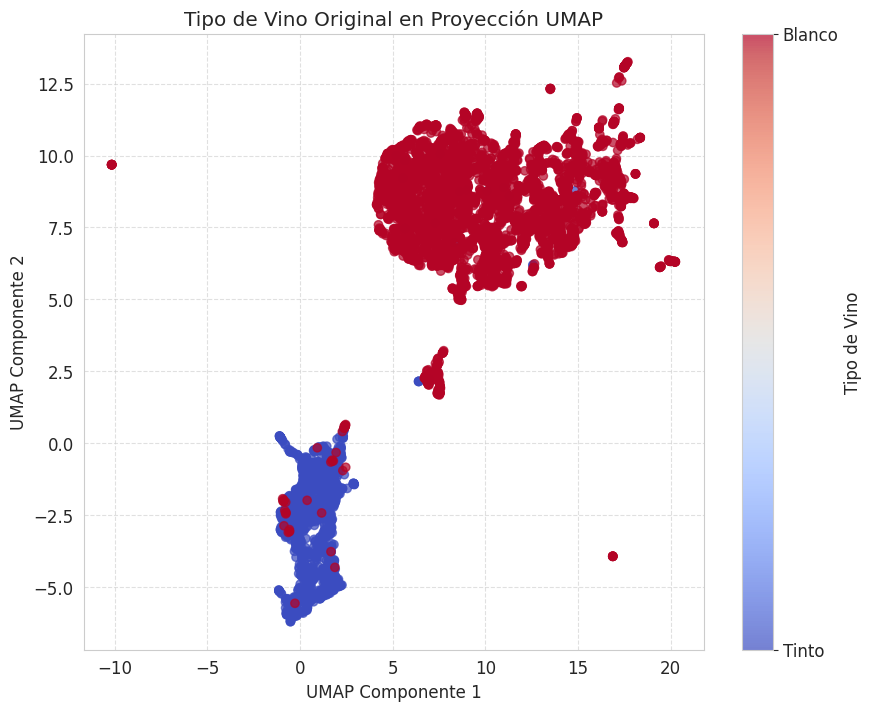

In [29]:
plt.figure(figsize=(10, 8))
scatter_original_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_type, cmap='coolwarm', alpha=0.7)
plt.title('Tipo de Vino Original en Proyección UMAP')
plt.xlabel('UMAP Componente 1')
plt.ylabel('UMAP Componente 2')
plt.colorbar(scatter_original_umap, ticks=[0, 1], format=plt.FuncFormatter(lambda x, p: 'Tinto' if x==0 else 'Blanco'), label='Tipo de Vino')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<a name="conclusion_reduccion"></a>
### 5.5. Conclusión de Reducción de Dimensionalidad
Una vez generadas todas las proyecciones visuales, es momento de analizar cuál método ofrece la visión más clara y útil de la estructura de los datos y de los clusters encontrados.

Al comparar las proyecciones de PCA, t-SNE y UMAP, KMeans separa mejor en todas ellas debido a que los datos tienen forma esférica. UMAP es el que mejor permite visualizar la separación de los clusters obtenidos porque los grupos aparecen más definidos y con menos superposición. En PCA los clusters se ven más mezclados, ya que no logra capturar las relaciones más complejas entre las variables. En el caso de t-SNE, la separación es válida, aunque tiende a fragmentar los grupos en varias "islas", lo que a veces dificulta interpretar la estructura general. En definitiva, considero que UMAP es el que mejor conserva esa separación natural, ya que se observa una división más clara entre ambos tipos. PCA muestra más mezcla entre tintos y blancos, mientras que t-SNE los separa pero de manera más dispersa.

En la proyección de UMAP observo que los vinos blancos forman grupos más compactos que están más apartados de los clusters de vinos tintos.
En t-SNE también se ven distinciones entre tintos y blancos, pero con más "islas" de puntos que parecen fragmentarse en subgrupos. Mientras que PCA presenta la separación menos clara entre tintos y blancos: los dos grupos tienden a mezclarse más.

Algunas estructuras interesantes que pude observar son la aparición de sub-grupos dentro de los clusters, mayormente en t-SNE, donde se ven divisiones más claras. Esta subdivisión podría estar reflejando diferencias internas en las características químicas del vino, como variaciones en acidez, alcohol o azúcares residuales, que no eran tan evidentes en PCA o incluso en UMAP.
En UMAP se nota cierta continuidad entre algunos grupos, mostrando transiciones graduales en lugar de separaciones totalmente rígidas.

En términos de velocidad, PCA fue el más rápido, seguido por UMAP. t-SNE fue el más lento, lo cual es esperable para datasets de este tamaño.
Si tuviera que trabajar con un dataset muy grande, elegiría PCA porque demanda poco cómputo, y usaría UMAP cuando el dataset sea más chico para lograr una clusterización más detallada.

Basado en la claridad visual, la preservación de estructuras y el rendimiento, considero que UMAP es la técnica más efectiva para visualizar este dataset porque es el que más separa los cluster y no demanda tanto costo computacional debido al tamaño del dataset.


<a name="final"></a>
## 6. Conclusiones Finales
Resumo a continuación los hallazgos clave de todo el proyecto.

**Hallazgos clave**

A través del clustering pude descubrir que los datos de vino no están distribuidos de manera aleatoria, ya que están separados entre vinos tintos y blancos.

También detecté algunos puntos aislados que podrían representar combinaciones poco comunes de variables. Por otro lado, pude observar que los gráficos poseen una forma circular tanto para K-means como para DBSCAN.

Las técnicas de reducción de dimensionalidad me ayudaron a visualizar mejor las variables que no eran evidentes al analizar los datos crudos, dándome mayor claridad entre tintos y blancos.

t-SNE me mostró mayores sub-grupos y algunos outliers. Por el contrario, UMAP me dio una visión más equilibrada y clara de la estructura general, mostrando mejor la separación entre vinos.

Sí, considero que los clusters pueden reflejar patrones de los datos que podrían estar asociados a ciertas características fisicoquímicas, como el tipo de vino (tinto/blanco). A su vez, puede haber subdivisiones que marquen la calidad de cada uno.

**Desafíos y aprendizajes**

En este trabajo de aprendizaje no supervisado, uno de los principales desafíos fue la ausencia de etiquetas que permitieran evaluar directamente el desempeño de los modelos. A diferencia del aprendizaje supervisado, acá no contamos con una "verdad" contra la cual comparar los resultados, por lo que la validación depende de métricas internas y, sobre todo, de la interpretación de la estructura de los datos.

Al aplicar DBSCAN, surgió una dificultad importante: el algoritmo no lograba generar al menos dos clusters bien definidos, lo que impedía una evaluación adecuada. Esto puso en evidencia la sensibilidad del método a sus hiperparámetros y a la estructura de densidad del dataset. DBSCAN funciona mejor cuando existen regiones claramente diferenciadas por densidad; si esa condición no se cumple, puede agrupar casi todos los puntos en un único cluster o clasificarlos como ruido. En este caso, el comportamiento del algoritmo no fue un error técnico, sino una señal sobre la geometría de los datos.

Finalmente, K-means resultó ser el modelo más adecuado para este dataset, ya que logró generar clusters diferenciados y evaluables. Esto sugiere que la estructura de los datos se ajusta mejor a las hipótesis de este algoritmo, que asume grupos aproximadamente esféricos y separables por centroides.

Como aprendizaje clave, me llevo que para analizar un clustering es importante tener en cuenta el tipo de negocio y conocer el contexto de los datos. También aprendí que la reducción de dimensionalidad es una herramienta fundamental para comprender estructuras complejas: técnicas como UMAP y t-SNE me permitieron visualizar patrones, sub-grupos y outliers que no eran evidentes en el espacio original. Comprendí la importancia de ajustar hiperparámetros y contrastar distintos métodos, ya que cada técnica aporta una perspectiva diferente sobre los datos. En definitiva, este proyecto me permitió entender que no existe un algoritmo universalmente superior, sino que cada modelo responde a supuestos distintos sobre la estructura de los datos.

**Aplicaciones futuras**

A partir de este tipo de clustering se podrían detectar desvíos en diferentes áreas, por ejemplo de producción o de comercialización. Desde el lado de producción, podría señalar errores en el proceso o en la materia prima. Desde el lado comercial, podría usarse para segmentar clientes de acuerdo a su compra y preferencias.

En definitiva, este tipo de análisis permite descubrir y predecir patrones de comportamiento en función de mejorar la toma de decisiones, detectando patrones que no eran evidentes a simple vista en los datos.